In [3]:
install.packages("patchwork")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
library(data.table)
library(ranger)
library(carData)
library(ggplot2)
library(fastshap)
library(car)          # for VIF
library(patchwork) # combine plots (optional)

In [2]:
library(data.table)
final_df <- fread("derived_tables/EFP_site_year_with_climate_deadwood_forest_trait_500m_12Feb26.csv")

In [3]:
library(data.table)

dt <- copy(final_df)

# Show duplicated column names
dup_names <- names(dt)[duplicated(names(dt))]
print(unique(dup_names))

# Keep only the LAST occurrence of each name (drop earlier duplicates)
keep_idx <- rev(!duplicated(rev(names(dt))))
dt <- dt[, ..keep_idx]

[1] "p_mm"          "tair_mean_c"   "swin_mean_wm2" "vpd_gs_hpa"   


In [4]:

# set physically impossible values to NA
dt[tair_mean_c < -50 | tair_mean_c > 60, tair_mean_c := NA]
dt[vpd_gs_hpa < 0 | vpd_gs_hpa > 500, vpd_gs_hpa := NA]
dt[p_mm < 0 | p_mm > 10000, p_mm := NA]
dt[swin_mean_wm2  < 0 | swin_mean_wm2  > 500, swin_mean_wm2  := NA]

In [6]:
clim_vars <- c("p_mm","tair_mean_c","swin_mean_wm2","vpd_gs_hpa")

for (v in clim_vars) {
  an <- paste0(v, "_anom")
  if (!an %in% names(dt)) {
    dt[, (an) := get(v) - mean(get(v), na.rm = TRUE), by = site_id]
  }
}


In [7]:
### New cell after figuring out the sites dose not have the same cover year:
library(data.table)



# ------------------------------------------------------------
# 0) Ensure naming consistency (lowercase -> consistent)
# ------------------------------------------------------------
setnames(dt,
         old = c("site_id", "igbp"),
         new = c("SITE_ID", "IGBP"),
         skip_absent = TRUE)

# ------------------------------------------------------------
# 1) Remove CRO (optional, but recommended)
# ------------------------------------------------------------
dt <- dt[!is.na(IGBP) & IGBP != "CRO"]

# ------------------------------------------------------------
# 2) Order by site and year
# ------------------------------------------------------------
setorder(dt, SITE_ID, year)

# ------------------------------------------------------------
# 3) Identify site-specific availability windows
# ------------------------------------------------------------
dt[, has_dw := !is.na(deadwood_mean_pct_500m)]

site_windows <- dt[has_dw == TRUE,
                   .(dw_start = min(year),
                     dw_end   = max(year)),
                   by = SITE_ID]

dt <- merge(dt, site_windows, by = "SITE_ID", all.x = TRUE)

# ------------------------------------------------------------
# 4) deadwood_frac_site (site-normalized intensity, 0–1)
# ------------------------------------------------------------
dt[year >= dw_start & year <= dw_end,
   deadwood_frac_site :=
     deadwood_mean_pct_500m /
     max(deadwood_mean_pct_500m, na.rm = TRUE),
   by = SITE_ID]

dt[!is.finite(deadwood_frac_site), deadwood_frac_site := NA_real_]
dt[, deadwood_frac_site := pmin(pmax(deadwood_frac_site, 0), 1)]

# ------------------------------------------------------------
# 5) deadwood_cumfrac (cumulative fraction over available window)
# ------------------------------------------------------------
dt[year >= dw_start & year <= dw_end,
   deadwood_total :=
     sum(deadwood_mean_pct_500m, na.rm = TRUE),
   by = SITE_ID]

dt[year >= dw_start & year <= dw_end,
   deadwood_cumfrac :=
     cumsum(fifelse(is.na(deadwood_mean_pct_500m), 0,
                     deadwood_mean_pct_500m)) /
     deadwood_total,
   by = SITE_ID]

dt[!is.finite(deadwood_cumfrac), deadwood_cumfrac := NA_real_]
dt[, deadwood_cumfrac := pmin(pmax(deadwood_cumfrac, 0), 1)]

# ------------------------------------------------------------
# 6) deadwood_3yr (rolling legacy effect)
# ------------------------------------------------------------
dt[, deadwood_3yr := NA_real_]

dt[year >= dw_start & year <= dw_end,
   deadwood_3yr :=
     frollsum(
       fifelse(is.na(deadwood_mean_pct_500m), 0,
               deadwood_mean_pct_500m),
       n = 3,
       align = "right"
     ),
   by = SITE_ID]

# ------------------------------------------------------------
# 7) Optional: forest loss proxy (recommended)
# ------------------------------------------------------------
# Year-to-year forest change already exists:
#   forest_change_pp_yoy

# Also define cumulative forest loss since first available year
dt[year >= dw_start & year <= dw_end,
   forest_loss_cum :=
     forest_mean_pct_500m -
     forest_mean_pct_500m[year == dw_start][1],
   by = SITE_ID]

# ------------------------------------------------------------
# 8) Clean up helpers
# ------------------------------------------------------------
dt[, c("has_dw", "dw_start", "dw_end", "deadwood_total") := NULL]

In [8]:
names(dt)

[1] "SITE_ID"                        "year"                          
 [3] "uwue"                           "etmax"                         
 [5] "precipavail"                    "gavail"                        
 [7] "gsmax"                          "co2avail"                      
 [9] "g1"                             "ef"                            
[11] "efampl"                         "gppsat"                        
[13] "nepmax"                         "rb"                            
[15] "rbmax"                          "acue"                          
[17] "tz"                             "nyears"                        
[19] "location_lat"                   "location_long"                 
[21] "location_elev"                  "IGBP"                          
[23] "p_mm"                           "tair_mean_c"                   
[25] "swin_mean_wm2"                  "vpd_gs_hpa"                    
[27] "forest_mean_pct_500m"           "deadwood_mean_pct_500m"        
[29] "forest_change_pp_from_baseline" "forest_change_pp_yoy"          
[31] "Rooting_depth"                  "LeafN_area"                    
[33] "SLA"                            "Stem_conduit_density"          
[35] "LeafN_mass"                     "p_mm_anom"                     
[37] "tair_mean_c_anom"               "swin_mean_wm2_anom"            
[39] "vpd_gs_hpa_anom"                "deadwood_frac_site"            
[41] "deadwood_cumfrac"               "deadwood_3yr"                  
[43] "forest_loss_cum"

In [29]:
View(dt)

SITE_ID,year,uwue,etmax,precipavail,gavail,gsmax,co2avail,g1,ef,⋯,forest_change_pp_yoy,Rooting_depth,LeafN_area,SLA,Stem_conduit_density,LeafN_mass,deadwood_3yr,deadwood_frac_site,deadwood_cumfrac,forest_loss_cum
<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2009,7.6758122,0.23525256,yes,yes,0.0086978262,yes,0.3358437,0.3127321,⋯,NA,0.6918347,1.922857,9.927664,59.54188,22.42068,NA,NA,NA,NA
AR-SLu,2010,16.2402893,0.10641401,yes,yes,0.0026672316,yes,-0.5497535,0.1492497,⋯,NA,0.6918347,1.922857,9.927664,59.54188,22.42068,NA,NA,NA,NA
AR-SLu,2011,10.6928793,0.13295070,yes,yes,0.0038752408,yes,-0.3088108,0.2533210,⋯,NA,0.6918347,1.922857,9.927664,59.54188,22.42068,NA,NA,NA,NA
AR-Vir,2010,4.0743924,0.32438591,yes,yes,0.0007750829,yes,-0.8520437,0.8271577,⋯,NA,1.0653660,1.432450,14.662185,32.99233,20.22492,NA,NA,NA,NA
AR-Vir,2011,3.7541200,0.26378451,yes,yes,0.0007116720,yes,-0.7099170,0.7727688,⋯,NA,1.0653660,1.432450,14.662185,32.99233,20.22492,NA,NA,NA,NA
AR-Vir,2012,4.3087226,0.26984531,yes,yes,0.0006417871,yes,-1.0401099,0.6727284,⋯,NA,1.0653660,1.432450,14.662185,32.99233,20.22492,NA,NA,NA,NA
AT-Neu,2002,3.9662324,0.34183833,yes,yes,0.0252128596,yes,2.6204606,0.8719508,⋯,NA,0.3975373,1.235504,20.128896,60.71813,23.53272,NA,NA,NA,NA
AT-Neu,2003,4.5123157,0.28705336,yes,yes,0.0116077636,yes,1.0214599,0.8922966,⋯,NA,0.3975373,1.235504,20.128896,60.71813,23.53272,NA,NA,NA,NA
AT-Neu,2004,3.8121818,0.28086398,yes,yes,0.0235160029,yes,2.8260133,0.8910636,⋯,NA,0.3975373,1.235504,20.128896,60.71813,23.53272,NA,NA,NA,NA


In [9]:
targets <- c("gppsat","nepmax","etmax","uwue","gsmax")

pred_clim_trait <- c(
  "p_mm_anom","tair_mean_c_anom","swin_mean_wm2_anom","vpd_gs_hpa_anom",
  "Rooting_depth","LeafN_mass","LeafN_area","SLA","Stem_conduit_density"
)

pred_full <- c(
  pred_clim_trait,
  "deadwood_mean_pct_500m",
  "deadwood_3yr",
  "forest_change_pp_yoy"
)

# Safety: keep only columns that exist
pred_clim_trait <- intersect(pred_clim_trait, names(dt))
pred_full       <- intersect(pred_full, names(dt))

stopifnot(all(c("SITE_ID","year","IGBP") %in% names(dt)))

In [10]:
set.seed(42)

eval_years <- 2016:2025
eval_df <- dt[year %in% eval_years]
eval_df[, IGBP := as.factor(IGBP)]

# Define the "common required" columns for a fair comparison
required_full <- c("deadwood_mean_pct_500m","deadwood_3yr","forest_change_pp_yoy", "IGBP")
required_full <- intersect(required_full, names(eval_df))

# We'll define per-target common rows inside CV, but we also pre-check column existence
cat("Predictors baseline:", pred_clim_trait, "\n")
cat("Predictors full:", pred_full, "\n")

Predictors baseline: p_mm_anom tair_mean_c_anom swin_mean_wm2_anom vpd_gs_hpa_anom Rooting_depth LeafN_mass LeafN_area SLA Stem_conduit_density 
Predictors full: p_mm_anom tair_mean_c_anom swin_mean_wm2_anom vpd_gs_hpa_anom Rooting_depth LeafN_mass LeafN_area SLA Stem_conduit_density deadwood_mean_pct_500m deadwood_3yr forest_change_pp_yoy 


Collinearity checks (correlation and VIF)

In [11]:
# Numeric predictors only (exclude factors like IGBP)
num_preds <- pred_full[pred_full != "IGBP"]
num_preds <- num_preds[sapply(eval_df[, ..num_preds], is.numeric)]

cor_mat <- cor(eval_df[, ..num_preds], use = "pairwise.complete.obs")

# Show high correlations
thr <- 0.7
high_pairs <- which(abs(cor_mat) > thr & upper.tri(cor_mat), arr.ind = TRUE)
if (nrow(high_pairs) > 0) {
  high_dt <- data.table(
    var1 = rownames(cor_mat)[high_pairs[,1]],
    var2 = colnames(cor_mat)[high_pairs[,2]],
    r = cor_mat[high_pairs]
  )[order(-abs(r))]
  print(high_dt)
} else {
  cat("No |r| >", thr, "pairs found.\n")
}

                     var1         var2          r
                   <char>       <char>      <num>
1: deadwood_mean_pct_500m deadwood_3yr  0.9207852
2:             LeafN_area          SLA -0.8658940


In [12]:
calc_vif <- function(d, y, preds) {
  d0 <- d[complete.cases(d[, c(y, preds), with=FALSE])]
  if (nrow(d0) < 50) return(NULL)
  f <- as.formula(paste(y, "~", paste(preds, collapse=" + ")))
  mod <- lm(f, data = as.data.frame(d0[, c(y, preds), with=FALSE]))
  vif_vals <- car::vif(mod)
  data.table(target=y, feature=names(vif_vals), VIF=as.numeric(vif_vals))[order(-VIF)]
}

# Example: VIF on eval_df for gppsat using full predictors
vif_gppsat <- calc_vif(eval_df, "gppsat", pred_full)
print(vif_gppsat)

    target                feature      VIF
    <char>                 <char>    <num>
 1: gppsat             LeafN_area 8.241268
 2: gppsat                    SLA 8.058062
 3: gppsat deadwood_mean_pct_500m 5.864296
 4: gppsat           deadwood_3yr 5.808602
 5: gppsat          Rooting_depth 2.634799
 6: gppsat   Stem_conduit_density 2.018596
 7: gppsat             LeafN_mass 1.978118
 8: gppsat        vpd_gs_hpa_anom 1.304443
 9: gppsat              p_mm_anom 1.226874
10: gppsat     swin_mean_wm2_anom 1.208843
11: gppsat       tair_mean_c_anom 1.164721
12: gppsat   forest_change_pp_yoy 1.043294


 Repeated site-blocked CV (baseline vs full) + ΔR² distribution

   target mean_R2_baseline mean_R2_full   mean_dR2     sd_dR2 n_splits
   <char>            <num>        <num>      <num>      <num>    <int>
1:  gsmax      -0.46838136   -0.2981585 0.17022285 0.48569704       30
2:  etmax       0.09409861    0.2374254 0.14332680 0.08185650       30
3: nepmax       0.36238397    0.4585672 0.09618328 0.05257738       30
4: gppsat       0.39636488    0.4699472 0.07358233 0.03677591       30
5:   uwue       0.11698565    0.1667185 0.04973289 0.06812283       30


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔR²' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔR²' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔR² (full − baseline) across repeated site-blocked splits' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔR² (full − baseline) across repeated site-blocked splits' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ΔR² (full − baseline) across repeated site-blocked splits' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label)

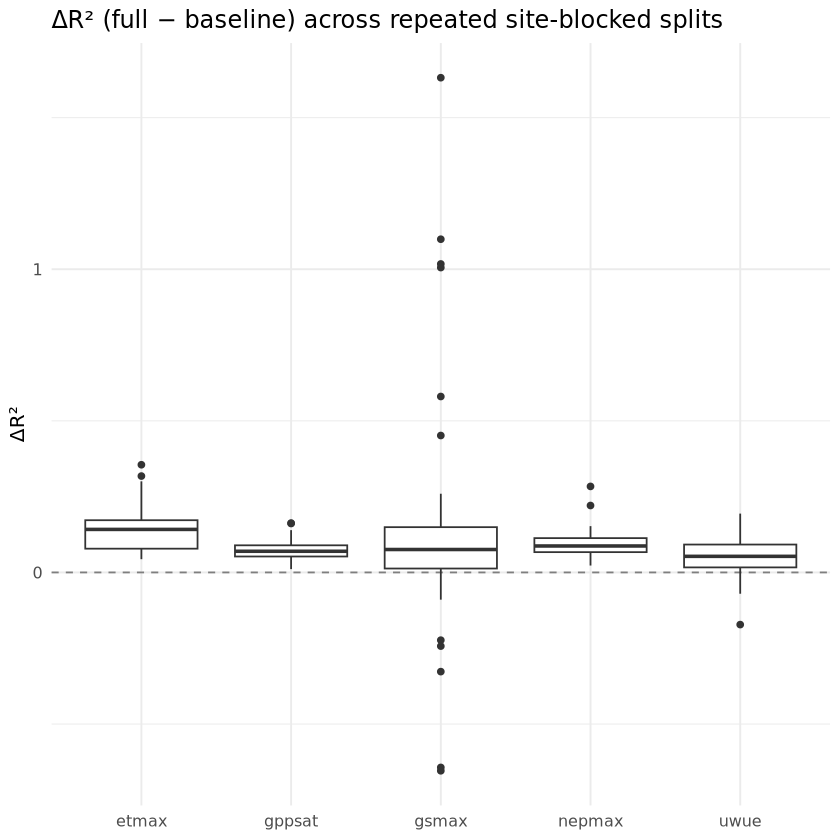

In [ ]:
rmse <- function(y, yhat) sqrt(mean((y - yhat)^2, na.rm = TRUE))
r2 <- function(y, yhat) {
  1 - sum((y - yhat)^2, na.rm = TRUE) /
    sum((y - mean(y, na.rm = TRUE))^2, na.rm = TRUE)
}

run_one_split <- function(eval_df, targets, pred_base, pred_full, test_frac=0.2, min_train=50, min_test=30) {
  sites <- unique(eval_df$SITE_ID)
  test_sites <- sample(sites, size = floor(test_frac * length(sites)))

  test_df  <- eval_df[SITE_ID %in% test_sites]
  train_df <- eval_df[!SITE_ID %in% test_sites]

  out <- list()

  for (y in targets) {
    # Common rows for BOTH models (fair)
    d_train <- train_df[
      !is.na(get(y)) &
        !is.na(deadwood_mean_pct_500m) &
        !is.na(deadwood_3yr) &
        !is.na(forest_change_pp_yoy) &
        !is.na(IGBP)
    ]
    d_test <- test_df[
      !is.na(get(y)) &
        !is.na(deadwood_mean_pct_500m) &
        !is.na(deadwood_3yr) &
        !is.na(forest_change_pp_yoy) &
        !is.na(IGBP)
    ]

    if (nrow(d_train) < min_train || nrow(d_test) < min_test) next

    base_use <- intersect(pred_base, names(d_train))
    full_use <- intersect(pred_full, names(d_train))

    # Baseline model
    f1 <- as.formula(paste(y, "~", paste(base_use, collapse = " + ")))
    m1 <- ranger(f1, data = d_train[, c(y, base_use), with=FALSE],
                 num.trees=500, importance="permutation")
    p1 <- predict(m1, data = d_test[, base_use, with=FALSE])$predictions

    # Full model
    f2 <- as.formula(paste(y, "~", paste(full_use, collapse = " + ")))
    m2 <- ranger(f2, data = d_train[, c(y, full_use), with=FALSE],
                 num.trees=500, importance="permutation")
    p2 <- predict(m2, data = d_test[, full_use, with=FALSE])$predictions

    out[[y]] <- data.table(
      target = y,
      RMSE_baseline = rmse(d_test[[y]], p1),
      R2_baseline   = r2(d_test[[y]], p1),
      RMSE_full     = rmse(d_test[[y]], p2),
      R2_full       = r2(d_test[[y]], p2),
      dR2           = r2(d_test[[y]], p2) - r2(d_test[[y]], p1),
      n_train = nrow(d_train),
      n_test  = nrow(d_test)
    )
  }

  rbindlist(out, fill=TRUE)
}

set.seed(42)
n_repeats <- 30
cv_res <- rbindlist(lapply(1:n_repeats, function(i) {
  set.seed(1000 + i)
  run_one_split(eval_df, targets, pred_clim_trait, pred_full)
}), fill=TRUE)

# Summary table
cv_summary <- cv_res[, .(
  mean_R2_baseline = mean(R2_baseline, na.rm=TRUE),
  mean_R2_full     = mean(R2_full, na.rm=TRUE),
  mean_dR2         = mean(dR2, na.rm=TRUE),
  sd_dR2           = sd(dR2, na.rm=TRUE),
  n_splits         = .N
), by = target][order(-mean_dR2)]

print(cv_summary)

# Plot ΔR² distribution (reviewer-proof)
ggplot(cv_res, aes(x = target, y = dR2)) +
  geom_hline(yintercept = 0, linetype = 2, color="grey50") +
  geom_boxplot() +
  theme_minimal(base_size = 12) +
  labs(
  title = expression(Delta*R^2*" (full - baseline) across repeated site-blocked splits"),
  y = expression(Delta*R^2)
)

Fit “final” models once (for SHAP) using a single site-blocked split

In [14]:
set.seed(42)

# Site-blocked split (one fixed split for interpretability plots)
sites <- unique(eval_df$SITE_ID)
test_sites <- sample(sites, size = floor(0.2 * length(sites)))

test_df  <- eval_df[SITE_ID %in% test_sites]
train_df <- eval_df[!SITE_ID %in% test_sites]

models <- list()
data_used <- list()

for (y in targets) {
  d_train <- train_df[
    !is.na(get(y)) &
      !is.na(deadwood_mean_pct_500m) &
      !is.na(deadwood_3yr) &
      !is.na(forest_change_pp_yoy) &
      !is.na(IGBP)
  ]
  d_test <- test_df[
    !is.na(get(y)) &
      !is.na(deadwood_mean_pct_500m) &
      !is.na(deadwood_3yr) &
      !is.na(forest_change_pp_yoy) &
      !is.na(IGBP)
  ]
  if (nrow(d_train) < 50 || nrow(d_test) < 30) next

  base_use <- intersect(pred_clim_trait, names(d_train))
  full_use <- intersect(pred_full, names(d_train))

  f1 <- as.formula(paste(y, "~", paste(base_use, collapse=" + ")))
  f2 <- as.formula(paste(y, "~", paste(full_use, collapse=" + ")))

  m1 <- ranger(f1, data = d_train[, c(y, base_use), with=FALSE],
               num.trees=500, importance="permutation")
  m2 <- ranger(f2, data = d_train[, c(y, full_use), with=FALSE],
               num.trees=500, importance="permutation")

  models[[y]] <- list(baseline=m1, full=m2, base_use=base_use, full_use=full_use)
  data_used[[y]] <- list(train=d_train, test=d_test)
}

SHAP: global beeswarm + mortality-by-IGBP effect

In [15]:
library(viridisLite)

shap_beeswarm <- function(shap_mat, X, top_n=12, title="SHAP summary", xlim_fixed=NULL) {
  sh_dt <- as.data.table(as.matrix(shap_mat))
  X_dt  <- as.data.table(X)

  imp <- sort(colMeans(abs(as.matrix(sh_dt)), na.rm=TRUE), decreasing=TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  sh_long <- melt(sh_dt[, ..feats], variable.name="feature", value.name="shap")
  x_long  <- melt(X_dt[,  ..feats], variable.name="feature", value.name="value")

  # Align by row order
  sh_long[, value := x_long$value]
  sh_long[, feature := factor(feature, levels = rev(feats))]

  sh_long[, value_scaled := {
    lo <- quantile(value, 0.05, na.rm=TRUE)
    hi <- quantile(value, 0.95, na.rm=TRUE)
    v  <- (value - lo) / (hi - lo)
    pmin(pmax(v, 0), 1)
  }, by=feature]

  p <- ggplot(sh_long, aes(x=shap, y=feature, color=value_scaled)) +
    geom_vline(xintercept=0, linewidth=0.4, color="grey50") +
    geom_point(position=position_jitter(height=0.18, width=0),
               size=1.1, alpha=0.85) +
    scale_color_viridis_c(option="D", name="Feature value",
                          breaks=c(0,1), labels=c("Low","High")) +
    theme_minimal(base_size=12) +
    theme(panel.grid.major.y=element_blank(),
          panel.grid.minor=element_blank()) +
    labs(title=title, x="SHAP value (impact on model output)", y=NULL)

  if (!is.null(xlim_fixed)) p <- p + coord_cartesian(xlim=xlim_fixed)
  p
}

In [16]:
dir.create("shap_outputs", showWarnings = FALSE)

for (y in names(models)) {
  m <- models[[y]]$full
  d_train <- data_used[[y]]$train

  X <- d_train[, models[[y]]$full_use, with=FALSE]

  set.seed(42)
  sh <- fastshap::explain(
    object = m,
    X = X,
    pred_wrapper = function(object, newdata) predict(object, data=newdata)$predictions,
    nsim = 100
  )

  xlim_fixed <- range(as.matrix(sh), na.rm=TRUE)

  p_all <- shap_beeswarm(sh, X, top_n=12,
                         title=paste0(y, " – SHAP summary (full model)"),
                         xlim_fixed=xlim_fixed)

  ggsave(file.path("shap_outputs", paste0("beeswarm_", y, "_all.png")),
         p_all, width=8, height=5, dpi=300)

  # Save objects for biome analysis
  saveRDS(list(sh=sh, X=X, meta=d_train[, .(SITE_ID, year, IGBP)]),
          file=file.path("shap_outputs", paste0("shapobj_", y, ".rds")))
}

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”

In [21]:
dir.create("shap_outputs_by_igbp", showWarnings = FALSE)

mort_feats <- c("deadwood_mean_pct_500m","deadwood_3yr","forest_change_pp_yoy")

for (y in names(models)) {
  obj <- readRDS(file.path("shap_outputs", paste0("shapobj_", y, ".rds")))
  sh <- as.data.table(as.matrix(obj$sh))
  meta <- obj$meta

  # Long shap for mortality features
  feats <- intersect(mort_feats, names(sh))
  sh_m <- cbind(meta, sh[, ..feats])
  sh_long <- melt(sh_m, id.vars=c("SITE_ID","year","IGBP"),
                  variable.name="feature", value.name="shap")

  # Boxplot: SHAP(mortality) by IGBP
  p_box <- ggplot(sh_long[!is.na(IGBP)],
                  aes(x=IGBP, y=shap)) +
    geom_hline(yintercept=0, linetype=2, color="grey50") +
    geom_boxplot(outlier.alpha=0.2) +
    facet_wrap(~feature, scales="free_y") +
    theme_minimal(base_size=12) +
    theme(axis.text.x=element_text(angle=45, hjust=1)) +
    labs(title=paste0(y, " – Mortality/forest SHAP by IGBP"),
         x=NULL, y="SHAP value")

  ggsave(file.path("shap_outputs_by_igbp", paste0("box_mortality_byIGBP_", y, ".png")),
         p_box, width=10, height=6, dpi=300)

  # Heatmap: mean |SHAP| per IGBP x feature
  hm <- sh_long[, .(mean_abs_shap = mean(shap, na.rm=TRUE),
                    n = .N), by=.(IGBP, feature)]

  p_hm <- ggplot(hm, aes(x=feature, y=IGBP, fill=mean_abs_shap)) +
    geom_tile() +
    theme_minimal(base_size=12) +
    theme(axis.text.x=element_text(angle=45, hjust=1)) +
    labs(title=paste0(y, " – Mean |SHAP| (mortality/forest) by IGBP"),
         x=NULL, y=NULL)

  ggsave(file.path("shap_outputs_by_igbp", paste0("heatmap_meanSHAP_byIGBP_", y, ".png")),
         p_hm, width=8, height=5, dpi=300)
}

dot-whisker” plot for each EFP (SHAP-based)

In [28]:
dir.create("gomarasca_style", showWarnings = FALSE)

predictor_groups <- function(f) {
  if (f %in% c("p_mm_anom","tair_mean_c_anom","swin_mean_wm2_anom","vpd_gs_hpa_anom")) return("Climate")
  if (f %in% c("Rooting_depth","LeafN_mass","LeafN_area","SLA","Stem_conduit_density")) return("Plant traits")
  if (f %in% c("deadwood_mean_pct_500m","deadwood_3yr","forest_change_pp_yoy")) return("Mortality/forest")
  "Other"
}

bootstrap_ci <- function(x, nboot=500, probs=c(0.025,0.975)) {
  x <- x[is.finite(x)]
  if (length(x) < 10) return(c(NA_real_, NA_real_))
  bs <- replicate(nboot, mean(sample(x, replace=TRUE)))
  quantile(bs, probs=probs, na.rm=TRUE)
}

for (y in names(models)) {
  obj <- readRDS(file.path("shap_outputs", paste0("shapobj_", y, ".rds")))
  sh <- as.data.table(as.matrix(obj$sh))
  feats <- names(sh)

  # summary stats per feature
  summ <- rbindlist(lapply(feats, function(f) {
    ci <- bootstrap_ci(sh[[f]], nboot=300)
    data.table(
      feature = f,
      mean_shap = mean(sh[[f]], na.rm=TRUE),
      lo = ci[1],
      hi = ci[2],
      mean_abs = mean(abs(sh[[f]]), na.rm=TRUE)
    )
  }))

  summ[, group := vapply(feature, predictor_groups, character(1))]
  summ <- summ[group %in% c("Climate","Plant traits","Mortality/forest")]

  # relative importance bins (for size)
  summ[, rel_imp := mean_abs / max(mean_abs, na.rm=TRUE)]
  summ[, size_bin := cut(rel_imp,
                         breaks=c(0,0.1,0.2,0.3,0.4,1),
                         labels=c("0–10%","10–20%","20–30%","30–40%","40–100%"),
                         include.lowest=TRUE)]

  # order by importance
  setorder(summ, -mean_abs)
  summ[, feature := factor(feature, levels=rev(feature))]

  p <- ggplot(summ, aes(x=mean_shap, y=feature, color=group)) +
    geom_vline(xintercept=0, color="grey50") +
    geom_errorbarh(aes(xmin=lo, xmax=hi), height=0.2, alpha=0.8) +
    geom_point(aes(size=size_bin), alpha=0.9) +
    scale_color_manual(values=c("Climate"="#2C7BB6",
                                "Plant traits"="#1A9850",
                                "Mortality/forest"="#F28E2B")) +
    theme_minimal(base_size=12) +
    labs(title=paste0(y, " – SHAP effect summary (dot-whisker)"),
         x="Mean SHAP effect (direction)", y=NULL, color="Predictor type", size="Relative importance") +
    theme(panel.grid.minor=element_blank())

  ggsave(file.path("gomarasca_style", paste0("dotwhisker_", y, ".png")),
         p, width=9, height=5, dpi=300)
}

Warning message:
“Using size for a discrete variable is not advised.”
Warning message:
“Using size for a discrete variable is not advised.”
Warning message:
“Using size for a discrete variable is not advised.”
Warning message:
“Using size for a discrete variable is not advised.”
Warning message:
“Using size for a discrete variable is not advised.”
